# Credit Risk Prediction System ⭐

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("cs-training.csv")
df.sample(20)

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
143048,143049,0,1.000000,53,0,0.142195,7116.0,3,0,0,0,0.0
83258,83259,0,0.244272,55,0,0.067802,6400.0,8,0,0,0,0.0
107049,107050,0,0.037399,88,0,0.290271,1880.0,2,0,0,0,0.0
145821,145822,0,0.000435,49,0,0.000000,3600.0,3,0,0,0,0.0
111496,111497,0,0.074878,60,0,795.000000,NaN,21,0,0,0,0.0
122229,122230,0,0.994067,51,0,0.898139,3975.0,11,0,2,0,0.0
96737,96738,0,0.029865,48,1,2.193935,3000.0,9,0,2,0,2.0
48749,48750,0,1.000000,38,0,0.233383,2000.0,3,0,0,0,1.0
41129,41130,0,1.000000,53,0,3577.000000,NaN,6,0,3,0,0.0
96539,96540,0,0.359202,45,0,0.317359,5800.0,21,0,1,0,1.0


In [3]:
df.rename(columns={'SeriousDlqin2yrs': 'Default_Status'}, inplace=True)

In [4]:
df.rename(columns={'RevolvingUtilizationOfUnsecuredLines': 'Credit_Utilization'}, inplace=True)

In [5]:
df.rename(columns={'NumberOfTime30-59DaysPastDueNotWorse': 'Late_30_59_Days'}, inplace=True)

In [6]:
df.rename(columns={'NumberOfTime60-89DaysPastDueNotWorse': 'Late_60_89_Days'}, inplace=True)

In [7]:
df.head()

,Unnamed: 0,Default_Status,Credit_Utilization,age,Late_30_59_Days,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,Late_60_89_Days,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


# Data Preprocess

df.info()

In [8]:
df.drop('Unnamed: 0', axis=1, inplace=True)

In [9]:
df['Default_Status'].value_counts(normalize=True)

Default_Status
0    0.93316
1    0.06684
Name: proportion, dtype: float64

In [10]:
df.isnull().sum()

Default_Status                         0
Credit_Utilization                     0
age                                    0
Late_30_59_Days                        0
DebtRatio                              0
MonthlyIncome                      29731
NumberOfOpenCreditLinesAndLoans        0
NumberOfTimes90DaysLate                0
NumberRealEstateLoansOrLines           0
Late_60_89_Days                        0
NumberOfDependents                  3924
dtype: int64

In [11]:
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())

In [12]:
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(df['NumberOfDependents'].mode()[0])

In [13]:
df.isnull().sum()

Default_Status                     0
Credit_Utilization                 0
age                                0
Late_30_59_Days                    0
DebtRatio                          0
MonthlyIncome                      0
NumberOfOpenCreditLinesAndLoans    0
NumberOfTimes90DaysLate            0
NumberRealEstateLoansOrLines       0
Late_60_89_Days                    0
NumberOfDependents                 0
dtype: int64

In [14]:
df['NumberOfDependents'] = df['NumberOfDependents'].astype(int)
df['MonthlyIncome'] = df['MonthlyIncome'].astype(int)

In [15]:
df = df[(df['age'] >= 18) & (df['age'] <= 100)].copy()
df['age'] = df['age'].astype(int)
print(df['age'].dtype)

int64


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 149986 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Default_Status                   149986 non-null  int64  
 1   Credit_Utilization               149986 non-null  float64
 2   age                              149986 non-null  int64  
 3   Late_30_59_Days                  149986 non-null  int64  
 4   DebtRatio                        149986 non-null  float64
 5   MonthlyIncome                    149986 non-null  int64  
 6   NumberOfOpenCreditLinesAndLoans  149986 non-null  int64  
 7   NumberOfTimes90DaysLate          149986 non-null  int64  
 8   NumberRealEstateLoansOrLines     149986 non-null  int64  
 9   Late_60_89_Days                  149986 non-null  int64  
 10  NumberOfDependents               149986 non-null  int64  
dtypes: float64(2), int64(9)
memory usage: 13.7 MB


In [17]:
df[['Late_30_59_Days','Late_60_89_Days','NumberOfTimes90DaysLate']].describe()

,Late_30_59_Days,Late_60_89_Days,NumberOfTimes90DaysLate
count,149986.000000,149986.000000,149986.000000
mean,0.421053,0.240409,0.265998
std,4.192973,4.155373,4.169498
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000
max,98.000000,98.000000,98.000000


In [18]:
df[['Credit_Utilization','DebtRatio','MonthlyIncome']].describe()

,Credit_Utilization,DebtRatio,MonthlyIncome
count,149986.000000,149986.000000,1.499860e+05
mean,6.048985,353.002995,6.418676e+03
std,249.767020,2037.902441,1.289096e+04
min,0.000000,0.000000,0.000000e+00
25%,0.029878,0.175075,3.903250e+03
50%,0.154234,0.366503,5.400000e+03
75%,0.559053,0.868100,7.400000e+03
max,50708.000000,329664.000000,3.008750e+06


In [19]:
late_cols = ['Late_30_59_Days','Late_60_89_Days','NumberOfTimes90DaysLate']

for col in late_cols:
    df[col] = df[col].replace([96,97,98], df[col].median())

In [20]:
for col in ['Credit_Utilization','DebtRatio','MonthlyIncome']:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)

In [21]:
df[['Late_30_59_Days',
    'Late_60_89_Days',
    'NumberOfTimes90DaysLate',
    'Credit_Utilization',
    'DebtRatio',
    'MonthlyIncome']].describe()

,Late_30_59_Days,Late_60_89_Days,NumberOfTimes90DaysLate,Credit_Utilization,DebtRatio,MonthlyIncome
count,149986.000000,149986.000000,149986.000000,149986.000000,149986.000000,149986.000000
mean,0.245356,0.064713,0.090302,0.320508,316.548985,6142.640846
std,0.697243,0.329803,0.485129,0.352152,907.008053,3835.763455
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.029878,0.175075,3903.250000
50%,0.000000,0.000000,0.000000,0.154234,0.366503,5400.000000
75%,0.000000,0.000000,0.000000,0.559053,0.868100,7400.000000
max,13.000000,11.000000,17.000000,1.092987,4979.600000,23000.000000


In [22]:
import numpy as np
df['DebtRatio'] = np.log1p(df['DebtRatio'])

In [23]:
df['DebtRatio'].describe()

count    149986.000000
mean          1.521618
std           2.617369
min           0.000000
25%           0.161332
50%           0.312255
75%           0.624922
max           8.513306
Name: DebtRatio, dtype: float64

In [24]:
df.sample(2)

,Default_Status,Credit_Utilization,age,Late_30_59_Days,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,Late_60_89_Days,NumberOfDependents
138161,0,1.00000,42,1,0.251695,3500,1,0,1,1,0
118153,0,0.18154,58,1,0.333237,6500,20,0,2,0,0


In [25]:
df['DebtRatio'].describe()

count    149986.000000
mean          1.521618
std           2.617369
min           0.000000
25%           0.161332
50%           0.312255
75%           0.624922
max           8.513306
Name: DebtRatio, dtype: float64

<Axes: xlabel='DebtRatio', ylabel='Count'>

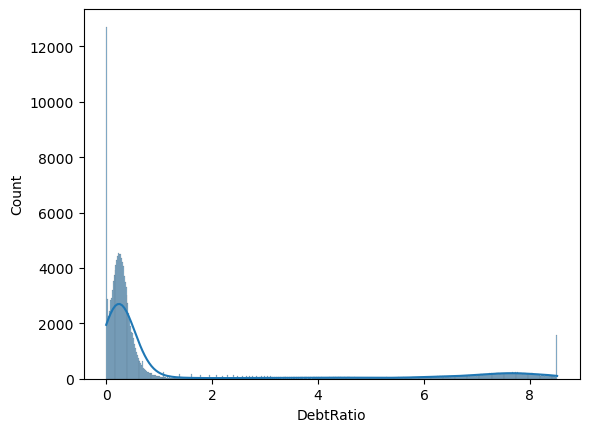

In [26]:
sns.histplot(df['DebtRatio'], kde=True)

# Feature Engineering

In [27]:
df['TotalLatePayments'] = (df['Late_30_59_Days'] +df['Late_60_89_Days'] +df['NumberOfTimes90DaysLate'])

In [28]:
df['TotalLatePayments']

0         2
1         0
2         2
3         0
4         1
         ..
149995    0
149996    0
149997    0
149998    0
149999    0
Name: TotalLatePayments, Length: 149986, dtype: int64

In [29]:
df['Any90DayLate'] = (
    df['NumberOfTimes90DaysLate'] > 0
).astype(int)

In [30]:
df['Any90DayLate']

0         0
1         0
2         1
3         0
4         0
         ..
149995    0
149996    0
149997    0
149998    0
149999    0
Name: Any90DayLate, Length: 149986, dtype: int64

In [31]:
df['IncomePerDependent'] = (df['MonthlyIncome'] /(df['NumberOfDependents'] + 1))

In [32]:
df['IncomePerDependent']

0          3040.000000
1          1300.000000
2          3042.000000
3          3300.000000
4         23000.000000
              ...     
149995     2100.000000
149996     1861.333333
149997     5400.000000
149998     5716.000000
149999     8158.000000
Name: IncomePerDependent, Length: 149986, dtype: float64

In [33]:
df['TotalCreditLines'] = (df['NumberOfOpenCreditLinesAndLoans'] +df['NumberRealEstateLoansOrLines'])
df['TotalCreditLines']

0         19
1          4
2          2
3          5
4          8
          ..
149995     5
149996     5
149997    19
149998     4
149999    10
Name: TotalCreditLines, Length: 149986, dtype: int64

In [34]:
df['HighUtilizationFlag'] = (df['Credit_Utilization'] > 0.75).astype(int)
df['HighUtilizationFlag']

0         1
1         1
2         0
3         0
4         1
         ..
149995    0
149996    0
149997    0
149998    0
149999    1
Name: HighUtilizationFlag, Length: 149986, dtype: int64

In [35]:
df['DebtLoad'] = (df['DebtRatio'] * df['MonthlyIncome'])
df['DebtLoad']

0          5375.711335
1           299.006404
2           248.484172
3           116.869824
4           566.262697
              ...     
149995      426.400143
149996     3017.166879
149997    44610.848013
149998        0.000000
149999     1819.805143
Name: DebtLoad, Length: 149986, dtype: float64

In [36]:
df['LatePerCreditLine'] = ( df['TotalLatePayments'] /(df['TotalCreditLines'] + 1))
df['LatePerCreditLine']

0         0.100000
1         0.000000
2         0.666667
3         0.000000
4         0.111111
            ...   
149995    0.000000
149996    0.000000
149997    0.000000
149998    0.000000
149999    0.000000
Name: LatePerCreditLine, Length: 149986, dtype: float64

In [37]:
df['UtilizationPerLine'] = (df['Credit_Utilization'] /(df['TotalCreditLines'] + 1))
df['UtilizationPerLine'] 

0         0.038306
1         0.191430
2         0.219393
3         0.038968
4         0.100804
            ...   
149995    0.006779
149996    0.049958
149997    0.012302
149998    0.000000
149999    0.077298
Name: UtilizationPerLine, Length: 149986, dtype: float64

In [38]:
df['HasDependents'] = (df['NumberOfDependents'] > 0).astype(int)
df['HasDependents']

0         1
1         1
2         0
3         0
4         0
         ..
149995    0
149996    1
149997    0
149998    0
149999    0
Name: HasDependents, Length: 149986, dtype: int64

In [39]:
df['SeniorFlag'] = (df['age'] >= 60).astype(int)
df['SeniorFlag']

0         0
1         0
2         0
3         0
4         0
         ..
149995    1
149996    0
149997    0
149998    0
149999    1
Name: SeniorFlag, Length: 149986, dtype: int64

In [40]:
df['ZeroIncomeFlag'] = (df['MonthlyIncome'] == 0).astype(int)
df['ZeroIncomeFlag']

0         0
1         0
2         0
3         0
4         0
         ..
149995    0
149996    0
149997    0
149998    0
149999    0
Name: ZeroIncomeFlag, Length: 149986, dtype: int64

In [41]:
df.sample(2)

,Default_Status,Credit_Utilization,age,Late_30_59_Days,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,Late_60_89_Days,...,Any90DayLate,IncomePerDependent,TotalCreditLines,HighUtilizationFlag,DebtLoad,LatePerCreditLine,UtilizationPerLine,HasDependents,SeniorFlag,ZeroIncomeFlag
136110,0,0.019769,51,0,0.085645,3600,6,0,0,0,...,0,1800.0,6,0,308.322298,0.000000,0.002824,1,0,0
45167,0,0.065897,92,1,4.248495,5400,5,0,0,0,...,0,5400.0,5,0,22941.874307,0.166667,0.010983,0,1,0


# 📊 Exploratory Data Analysis (EDA)

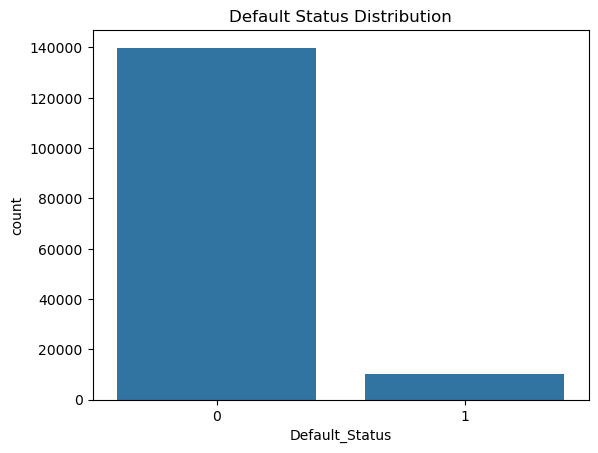

In [42]:
sns.countplot(x='Default_Status', data=df)
plt.title("Default Status Distribution")
plt.show()

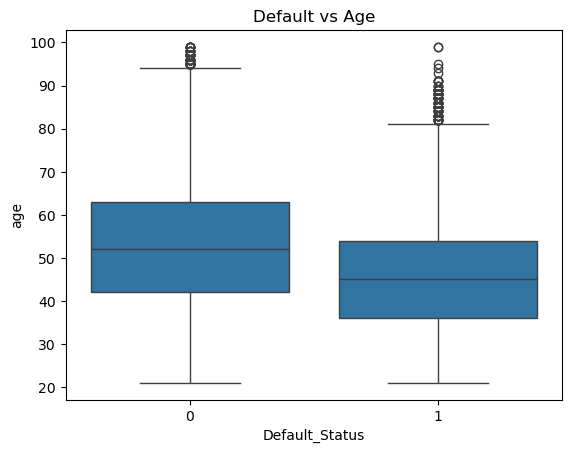

In [50]:
sns.boxplot(x='Default_Status', y='age', data=df)
plt.title("Default vs Age")
plt.show()

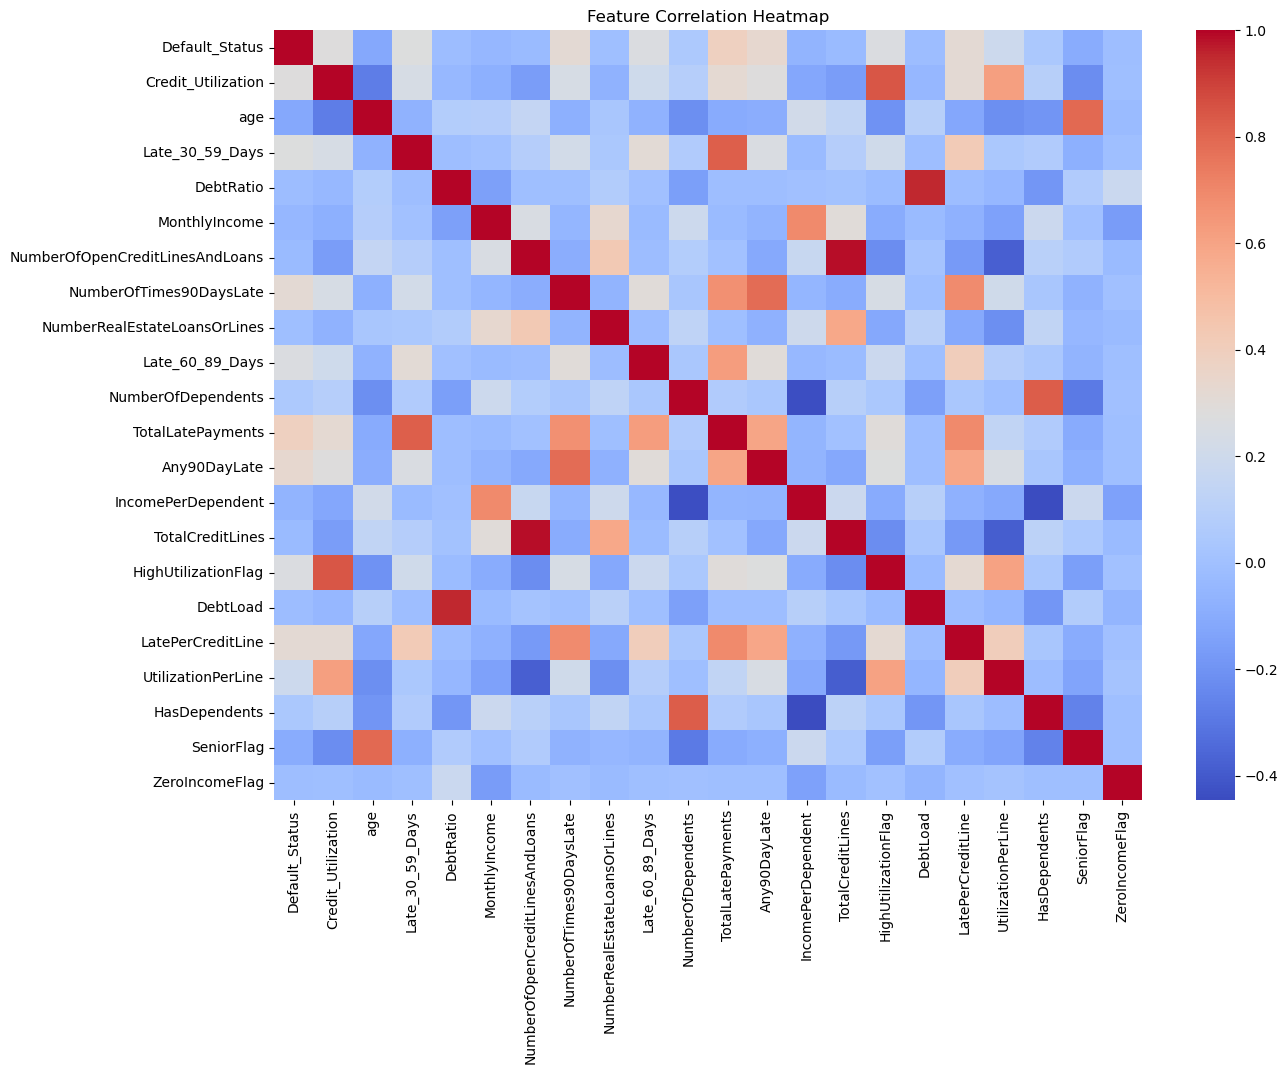

In [44]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [45]:
df.corr()['Default_Status'].sort_values(ascending=False)

Default_Status                     1.000000
TotalLatePayments                  0.388653
Any90DayLate                       0.329616
LatePerCreditLine                  0.313697
NumberOfTimes90DaysLate            0.311729
Credit_Utilization                 0.280856
Late_30_59_Days                    0.271364
Late_60_89_Days                    0.265608
HighUtilizationFlag                0.262462
UtilizationPerLine                 0.189373
NumberOfDependents                 0.046878
HasDependents                      0.043532
NumberRealEstateLoansOrLines      -0.007028
ZeroIncomeFlag                    -0.011114
DebtLoad                          -0.017066
DebtRatio                         -0.017337
TotalCreditLines                  -0.028041
NumberOfOpenCreditLinesAndLoans   -0.029667
MonthlyIncome                     -0.049784
IncomePerDependent                -0.062114
SeniorFlag                        -0.098823
age                               -0.115470
Name: Default_Status, dtype: flo

Text(0.5, 1.0, 'Credit Utilization Distribution')

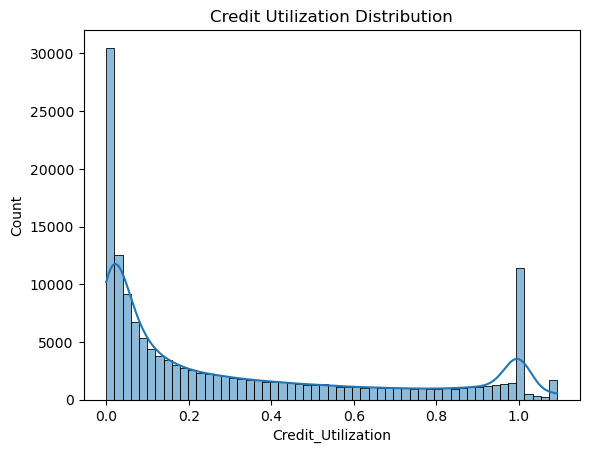

In [51]:
sns.histplot(df['Credit_Utilization'], kde=True)
plt.title("Credit Utilization Distribution")

<Axes: xlabel='Default_Status', ylabel='TotalCreditLines'>

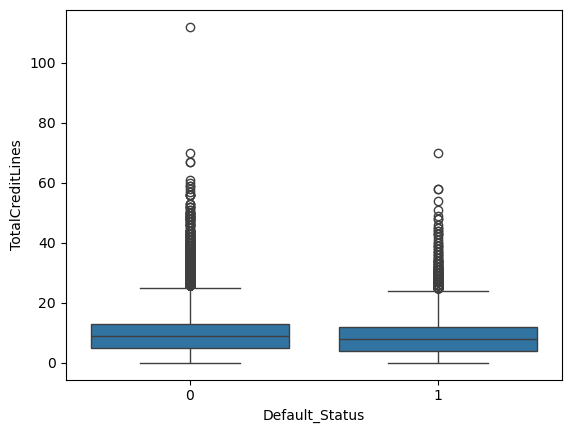

In [52]:
sns.boxplot(x='Default_Status', y='TotalCreditLines', data=df)

<Axes: xlabel='AgeGroup', ylabel='Default_Status'>

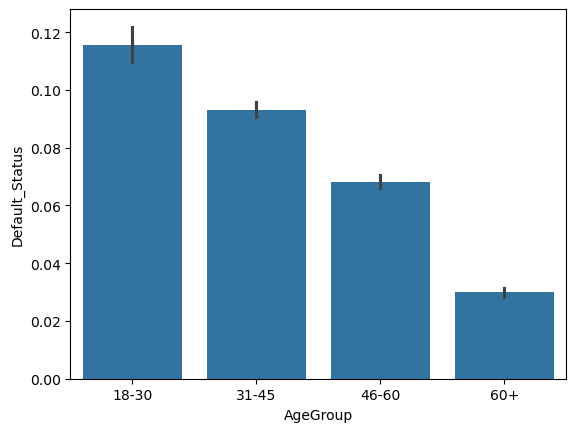

In [53]:
df['AgeGroup'] = pd.cut(df['age'],
                        bins=[18,30,45,60,100],
                        labels=['18-30','31-45','46-60','60+'])

sns.barplot(x='AgeGroup', y='Default_Status', data=df)

<Axes: xlabel='AgeGroup', ylabel='MonthlyIncome'>

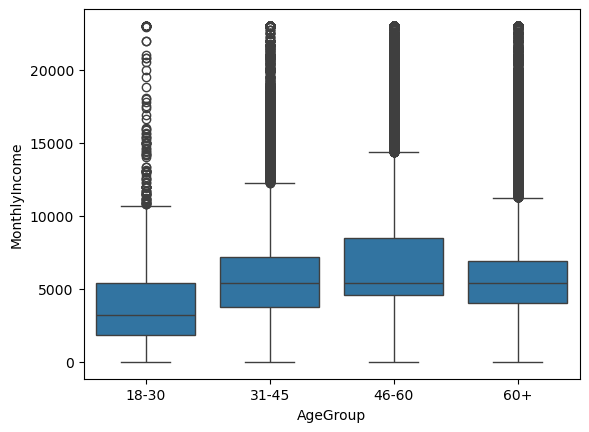

In [54]:
sns.boxplot(x='AgeGroup', y='MonthlyIncome', data=df)

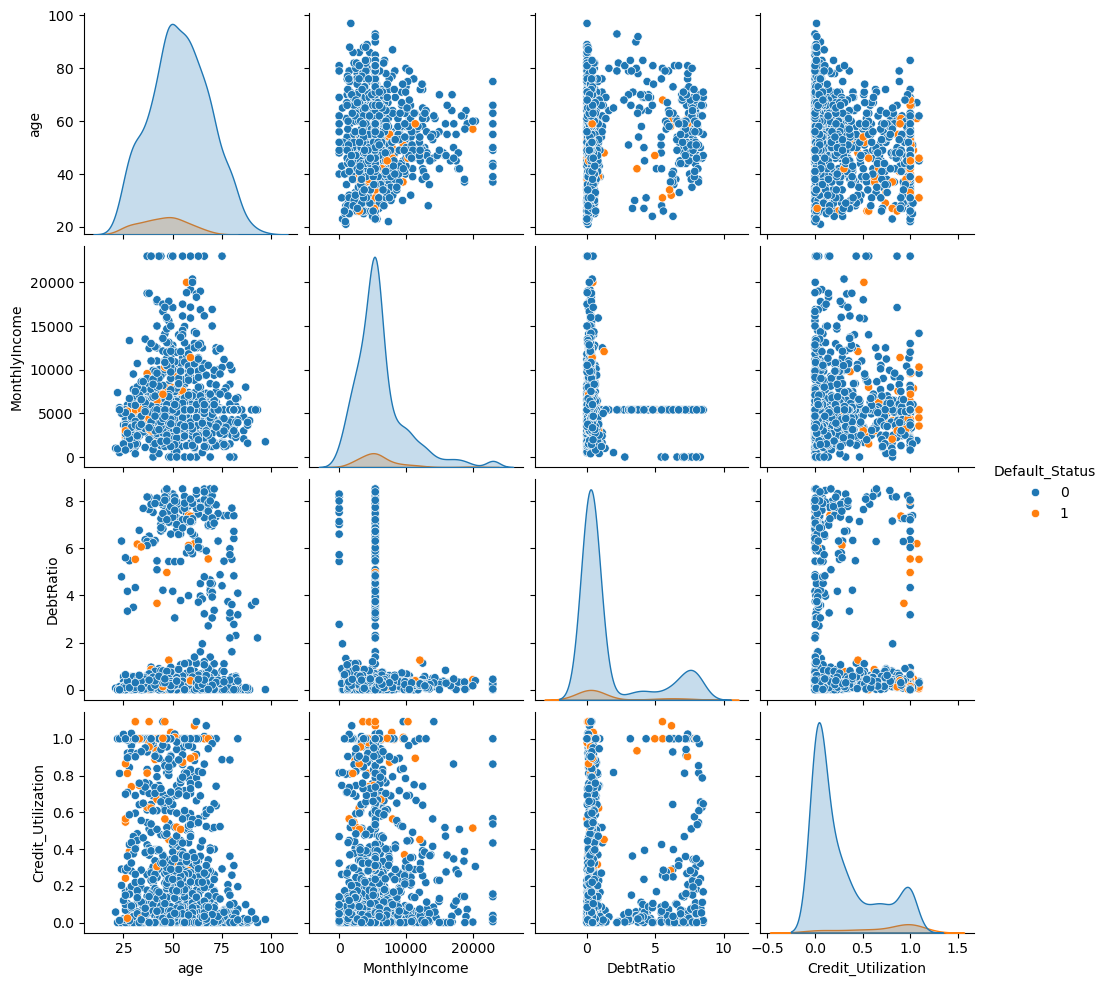

In [55]:
sample = df.sample(1000, random_state=42)

sns.pairplot(sample[
['age','MonthlyIncome','DebtRatio','Credit_Utilization','Default_Status']],
hue='Default_Status')

<Axes: xlabel='Credit_Utilization', ylabel='TotalLatePayments'>

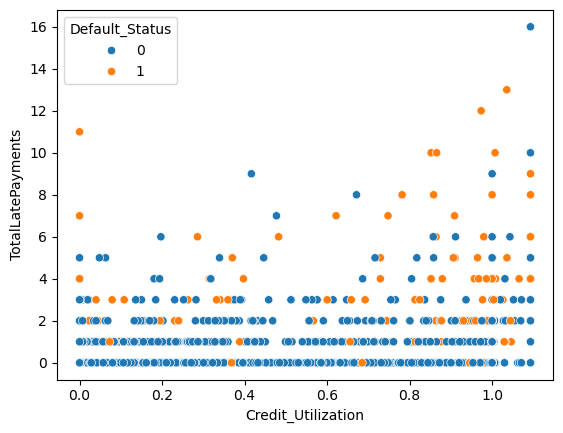

In [56]:
sns.scatterplot(x='Credit_Utilization',
                y='TotalLatePayments',
                hue='Default_Status',
                data=df.sample(3000))

Text(0.5, 1.0, 'Default Percentage')

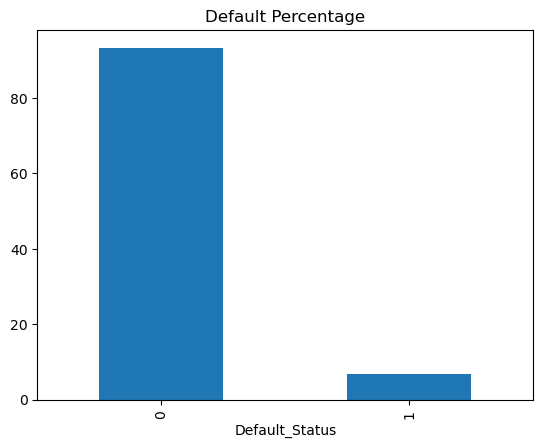

In [58]:
(df['Default_Status'].value_counts(normalize=True)*100).plot(kind='bar')
plt.title("Default Percentage")

In [94]:
import sweetviz as sv

report = sv.analyze(df)
report.show_html("sweetviz_report.html")

                                             |                                             | [  0%]   00:00 ->…

Report sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [59]:
df.sample(5)

,Default_Status,Credit_Utilization,age,Late_30_59_Days,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,Late_60_89_Days,...,IncomePerDependent,TotalCreditLines,HighUtilizationFlag,DebtLoad,LatePerCreditLine,UtilizationPerLine,HasDependents,SeniorFlag,ZeroIncomeFlag,AgeGroup
9159,0,0.000000,58,0,0.348038,12500,11,0,2,0,...,6250.0,13,0,4350.480555,0.000000,0.000000,1,0,0,46-60
106988,0,0.086431,68,0,5.337538,5400,8,0,0,0,...,5400.0,8,0,28822.705630,0.000000,0.009603,0,1,0,60+
112396,0,1.015112,65,0,7.401231,5400,8,0,1,0,...,5400.0,9,1,39966.648828,0.000000,0.101511,0,1,0,60+
10544,0,0.027998,89,0,0.115985,6000,11,0,1,0,...,3000.0,12,0,695.912542,0.000000,0.002154,1,1,0,60+
99191,1,0.937801,44,2,0.677858,2800,10,0,1,0,...,2800.0,11,1,1898.001666,0.166667,0.078150,0,0,0,31-45


# . Model Algorithms

In [71]:
X = df.drop(['Default_Status', 'AgeGroup'], axis=1)
y = df['Default_Status']

In [72]:
X

,Credit_Utilization,age,Late_30_59_Days,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,Late_60_89_Days,NumberOfDependents,...,Any90DayLate,IncomePerDependent,TotalCreditLines,HighUtilizationFlag,DebtLoad,LatePerCreditLine,UtilizationPerLine,HasDependents,SeniorFlag,ZeroIncomeFlag
0,0.766127,45,2,0.589442,9120,13,0,6,0,2,...,0,3040.000000,19,1,5375.711335,0.100000,0.038306,1,0,0
1,0.957151,40,0,0.115002,2600,4,0,0,0,1,...,0,1300.000000,4,1,299.006404,0.000000,0.191430,1,0,0
2,0.658180,38,1,0.081684,3042,2,1,0,0,0,...,1,3042.000000,2,0,248.484172,0.666667,0.219393,0,0,0
3,0.233810,30,0,0.035415,3300,5,0,0,0,0,...,0,3300.000000,5,0,116.869824,0.000000,0.038968,0,0,0
4,0.907239,49,1,0.024620,23000,7,0,1,0,0,...,0,23000.000000,8,1,566.262697,0.111111,0.100804,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,0.040674,74,0,0.203048,2100,4,0,1,0,0,...,0,2100.000000,5,0,426.400143,0.000000,0.006779,0,1,0
149996,0.299745,44,0,0.540324,5584,4,0,1,0,2,...,0,1861.333333,5,0,3017.166879,0.000000,0.049958,1,0,0
149997,0.246044,58,0,8.261268,5400,18,0,1,0,0,...,0,5400.000000,19,0,44610.848013,0.000000,0.012302,0,0,0
149998,0.000000,30,0,0.000000,5716,4,0,0,0,0,...,0,5716.000000,4,0,0.000000,0.000000,0.000000,0,0,0


In [73]:
y

0         1
1         0
2         0
3         0
4         0
         ..
149995    0
149996    0
149997    0
149998    0
149999    0
Name: Default_Status, Length: 149986, dtype: int64

In [74]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,stratify=y,random_state=42)

In [75]:
X_train

,Credit_Utilization,age,Late_30_59_Days,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,Late_60_89_Days,NumberOfDependents,...,Any90DayLate,IncomePerDependent,TotalCreditLines,HighUtilizationFlag,DebtLoad,LatePerCreditLine,UtilizationPerLine,HasDependents,SeniorFlag,ZeroIncomeFlag
89038,1.000000,26,0,0.000000,1600,0,0,0,0,1,...,0,800.0,0,1,0.000000,0.000,1.000000,1,0,0
76578,0.092256,48,0,0.374491,13300,17,0,2,0,0,...,0,13300.0,19,0,4980.735308,0.000,0.004613,0,0,0
14675,1.092987,35,2,0.584035,2877,5,1,2,2,0,...,1,2877.0,7,1,1680.267978,0.625,0.136623,0,0,0
47863,0.319296,58,0,0.479235,3800,6,0,1,0,0,...,0,3800.0,7,0,1821.092110,0.000,0.039912,0,0,0
86609,0.031614,46,0,0.262339,9200,8,0,2,0,3,...,0,2300.0,10,0,2413.520487,0.000,0.002874,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68160,0.037411,34,0,0.076007,6951,8,0,0,0,0,...,0,6951.0,8,0,528.324361,0.000,0.004157,0,0,0
34886,0.000000,56,0,0.174774,3900,9,0,0,0,1,...,0,1950.0,9,0,681.617446,0.000,0.000000,1,0,0
3736,0.485378,63,0,7.238497,5400,5,0,1,0,0,...,0,5400.0,6,0,39087.882941,0.000,0.069340,0,1,0
30299,0.276532,34,0,0.066656,2770,6,0,0,0,0,...,0,2770.0,6,0,184.638367,0.000,0.039505,0,0,0


In [76]:
X_test

,Credit_Utilization,age,Late_30_59_Days,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,Late_60_89_Days,NumberOfDependents,...,Any90DayLate,IncomePerDependent,TotalCreditLines,HighUtilizationFlag,DebtLoad,LatePerCreditLine,UtilizationPerLine,HasDependents,SeniorFlag,ZeroIncomeFlag
92230,0.117364,63,0,0.358549,5970,7,0,2,0,0,...,0,5970.000000,9,0,2140.537051,0.000000,0.011736,0,1,0
146800,0.737316,50,1,0.195833,7816,5,0,1,0,2,...,0,2605.333333,6,0,1530.628387,0.142857,0.105331,1,0,0
76051,0.451655,56,0,0.297471,5336,11,0,1,0,3,...,0,1334.000000,12,0,1587.305209,0.000000,0.034743,1,0,0
117643,0.158179,52,0,0.252203,6626,6,0,1,0,0,...,0,6626.000000,7,0,1671.094788,0.000000,0.019772,0,0,0
21984,0.892104,34,0,0.422400,4000,6,1,0,0,0,...,1,4000.000000,6,1,1689.599856,0.142857,0.127443,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64339,0.000000,50,0,0.163137,7200,9,0,2,0,1,...,0,3600.000000,11,0,1174.584297,0.000000,0.000000,1,0,0
10479,0.986716,36,0,0.452893,1900,5,0,0,0,0,...,0,1900.000000,5,1,860.497315,0.000000,0.164453,0,0,0
86558,0.054085,65,0,0.488637,4000,20,0,2,0,0,...,0,4000.000000,22,0,1954.546990,0.000000,0.002352,0,1,0
53577,0.400875,59,0,0.416621,7338,15,0,2,0,0,...,0,7338.000000,17,0,3057.166735,0.000000,0.022271,0,0,0


In [77]:
y_train

89038    0
76578    0
14675    1
47863    0
86609    0
        ..
68160    0
34886    0
3736     0
30299    0
74899    0
Name: Default_Status, Length: 119988, dtype: int64

In [78]:
y_test

92230     0
146800    1
76051     0
117643    0
21984     0
         ..
64339     0
10479     0
86558     0
53577     0
73688     0
Name: Default_Status, Length: 29998, dtype: int64

In [79]:
y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)

Default_Status
0    0.933162
1    0.066838
Name: proportion, dtype: float64

In [81]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [82]:
X_train_res

,Credit_Utilization,age,Late_30_59_Days,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,Late_60_89_Days,NumberOfDependents,...,Any90DayLate,IncomePerDependent,TotalCreditLines,HighUtilizationFlag,DebtLoad,LatePerCreditLine,UtilizationPerLine,HasDependents,SeniorFlag,ZeroIncomeFlag
0,1.000000,26,0,0.000000,1600,0,0,0,0,1,...,0,800.000000,0,1,0.000000,0.000000,1.000000,1,0,0
1,0.092256,48,0,0.374491,13300,17,0,2,0,0,...,0,13300.000000,19,0,4980.735308,0.000000,0.004613,0,0,0
2,1.092987,35,2,0.584035,2877,5,1,2,2,0,...,1,2877.000000,7,1,1680.267978,0.625000,0.136623,0,0,0
3,0.319296,58,0,0.479235,3800,6,0,1,0,0,...,0,3800.000000,7,0,1821.092110,0.000000,0.039912,0,0,0
4,0.031614,46,0,0.262339,9200,8,0,2,0,3,...,0,2300.000000,10,0,2413.520487,0.000000,0.002874,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223931,0.684280,58,0,1.185510,1861,21,0,2,0,0,...,0,1861.238444,23,0,2205.196870,0.024752,0.026282,0,0,0
223932,0.773194,37,2,0.599177,6508,11,0,1,0,2,...,0,2169.652673,12,0,3900.415603,0.205863,0.058398,1,0,0
223933,0.770470,57,3,0.545644,7627,11,0,2,2,2,...,0,2542.511178,13,0,4161.770810,0.344169,0.055497,1,0,0
223934,0.684690,39,2,0.347891,5893,10,0,1,0,3,...,0,1473.430523,12,0,2051.557481,0.195724,0.049119,1,0,0


In [83]:
y_train_res

0         0
1         0
2         1
3         0
4         0
         ..
223931    1
223932    1
223933    1
223934    1
223935    1
Name: Default_Status, Length: 223936, dtype: int64

In [84]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_res, y_train_res)

RandomForestClassifier(class_weight='balanced', min_samples_leaf=2,
                       min_samples_split=5, n_estimators=300, n_jobs=-1,
                       random_state=42)

In [85]:
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]

In [86]:
y_pred
y_prob

array([0.01709391, 0.34627052, 0.04998413, ..., 0.00944444, 0.1155874 ,
       0.03379087])

In [87]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.95      0.95     27993
           1       0.37      0.39      0.38      2005

    accuracy                           0.91     29998
   macro avg       0.66      0.67      0.67     29998
weighted avg       0.92      0.91      0.92     29998

ROC-AUC Score: 0.8445206866376374
[[26634  1359]
 [ 1218   787]]


In [98]:
sample = pd.DataFrame([{
 'Credit_Utilization':0.95,
 'age':44,
 'Late_30_59_Days':2,
 'DebtRatio':0.67,
 'MonthlyIncome':2800,
 'NumberOfOpenCreditLinesAndLoans':10,
 'NumberOfTimes90DaysLate':0,
 'NumberRealEstateLoansOrLines':1,
 'Late_60_89_Days':0,
 'NumberOfDependents':0,

 'TotalLatePayments':2,
 'Any90DayLate':0,
 'IncomePerDependent':2800,
 'TotalCreditLines':11,
 'HighUtilizationFlag':1,
 'DebtLoad':1876,
 'LatePerCreditLine':0.18,
 'UtilizationPerLine':0.08,
 'HasDependents':0,
 'SeniorFlag':0,
 'ZeroIncomeFlag':0
}])

In [100]:
rf.predict(sample)
rf.predict_proba(sample)
rf.predict(sample)

array([1])

In [101]:
import pickle

# Save model
pickle.dump(rf, open("credit_risk_model.pkl", "wb"))

# Save columns
pickle.dump(X.columns.tolist(), open("model_columns.pkl", "wb"))

# Save processed data
df.to_csv("processed_credit_risk.csv", index=False)